# Universidade Federal do Rio Grande do Norte
# Departamento de Engenharia da Computação e Automação
# DCA 3606 - Inteligencia Artificial
# RetinAI - Diagnostico de Retinopatia Diabética usando Inteligencia Artificial

Alunos:
1.   Carlos Gabriel Medeiros da Silva
2.   Daniel Bruno Trindade da Silva
1.   Joanderson Luan da Silva Linhares
2.   Maria Clara Moura de Freitas

# Importação de bibliotecas e acesso ao Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
pip install scikit-fuzzy opencv-python matplotlib numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 13.8 MB/s eta 0:00:00


#  Código para saber as estatisticas e montar as regras Fuzzy

Lendo /content/drive/MyDrive/2025.2/IA/dataset/test/negativo...
Lendo /content/drive/MyDrive/2025.2/IA/dataset/test/positivo...

=== ESTATÍSTICAS REAIS DO SEU DATASET ===
NEGATIVOS (Saudável) -> Média Verde: 134.73 | Desvio Padrão: 18.82
POSITIVOS (Doente)   -> Média Verde: 134.94 | Desvio Padrão: 11.65



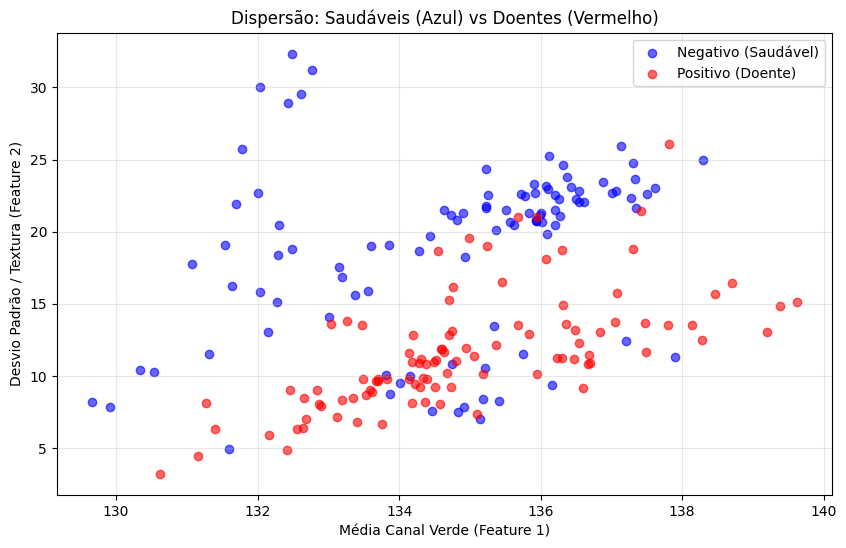

In [3]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# CONFIGURAÇÃO
# =========================================================
DATASET_DIR = '/content/drive/MyDrive/2025.2/IA/dataset/test' # Sua pasta
LIMIT_ANALYSIS = 100 # Analisar 100 de cada tipo para ser rápido

def get_stats(folder):
    means = []
    stds = []

    if not os.path.exists(folder):
        print(f"Pasta não encontrada: {folder}")
        return means, stds

    files = os.listdir(folder)
    print(f"Lendo {folder}...")

    for i, arq in enumerate(files[:LIMIT_ANALYSIS]):
        path = os.path.join(folder, arq)
        if not arq.lower().endswith(('.png', '.jpg', '.jpeg')):
            continue

        img = cv2.resize(cv2.imread(path), (64, 64))
        if img is None: continue

        # Canal Verde
        g = img[:, :, 1]

        means.append(np.mean(g))
        stds.append(np.std(g))

    return means, stds

# 1. Coletar dados
neg_m, neg_s = get_stats(os.path.join(DATASET_DIR, 'negativo'))
pos_m, pos_s = get_stats(os.path.join(DATASET_DIR, 'positivo'))

# 2. Calcular Médias Gerais
avg_neg_m = np.mean(neg_m) if neg_m else 0
avg_neg_s = np.mean(neg_s) if neg_s else 0
avg_pos_m = np.mean(pos_m) if pos_m else 0
avg_pos_s = np.mean(pos_s) if pos_s else 0

print("\n=== ESTATÍSTICAS REAIS DO SEU DATASET ===")
print(f"NEGATIVOS (Saudável) -> Média Verde: {avg_neg_m:.2f} | Desvio Padrão: {avg_neg_s:.2f}")
print(f"POSITIVOS (Doente)   -> Média Verde: {avg_pos_m:.2f} | Desvio Padrão: {avg_pos_s:.2f}")
print("==========================================\n")

# 3. Plotar Gráfico
plt.figure(figsize=(10, 6))
plt.scatter(neg_m, neg_s, color='blue', alpha=0.6, label='Negativo (Saudável)')
plt.scatter(pos_m, pos_s, color='red', alpha=0.6, label='Positivo (Doente)')

plt.xlabel('Média Canal Verde (Feature 1)')
plt.ylabel('Desvio Padrão / Textura (Feature 2)')
plt.title('Dispersão: Saudáveis (Azul) vs Doentes (Vermelho)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Código Lógica Fuzzy (Mamdani e Sugeno)

In [4]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import cv2
import os
import matplotlib.pyplot as plt

# =============================================================================
# 1. CONFIGURAÇÃO E EXTRAÇÃO DE CARACTERÍSTICAS
# =============================================================================

def extrair_features(caminho_imagem):
    """
    Extrai apenas o Desvio Padrão do canal verde, pois o gráfico mostrou
    que a Média Verde não ajuda a separar as classes neste dataset.
    """
    img = cv2.imread(caminho_imagem)
    if img is None:
        return None, None

    # Redimensionar (64x64)
    img = cv2.resize(img, (64, 64))

    # Canal Verde (G)
    canal_verde = img[:, :, 1]

    # Feature 1: Média (Mantemos o cálculo apenas para log, se necessário, mas não usamos no fuzzy)
    media_verde = float(np.mean(canal_verde))

    # Feature 2: Desvio Padrão (A característica discriminante)
    desvio_padrao = float(np.std(canal_verde))

    return media_verde, desvio_padrao

# =============================================================================
# 2. DEFINIÇÃO DO SISTEMA FUZZY (MAMDANI)
# =============================================================================

# Universo de Discurso para o Desvio Padrão (Feature discriminante)
# Seus dados variam aprox entre 0 e 35. Vamos dar uma margem até 50.
f_std   = ctrl.Antecedent(np.arange(0, 50, 0.5), 'contraste_textura')
risco   = ctrl.Consequent(np.arange(0, 101, 1), 'risco_retinopatia')

# Funções de Pertinência (Baseadas no seu Scatter Plot)
# Ponto de corte visual foi aprox 15.
# < 15: Doentes (Vermelhos) -> Baixo contraste/textura
# > 15: Saudáveis (Azuis)   -> Alto contraste/textura

f_std['baixo_doente']  = fuzz.trapmf(f_std.universe, [0, 0, 14, 16])
f_std['alto_saudavel'] = fuzz.trapmf(f_std.universe, [14, 16, 50, 50])

# Saída: Risco
risco['baixo'] = fuzz.trimf(risco.universe, [0, 0, 50])     # Saudável
risco['alto']  = fuzz.trimf(risco.universe, [50, 100, 100]) # Doente

# Regras
# Se Std é baixo (imagem borrada/lisa) -> É Doente -> Risco Alto
# Se Std é alto (imagem texturizada)   -> É Saudável -> Risco Baixo
r1 = ctrl.Rule(f_std['baixo_doente'], risco['alto'])
r2 = ctrl.Rule(f_std['alto_saudavel'], risco['baixo'])

sistema_controle = ctrl.ControlSystem([r1, r2])
simulador_mamdani = ctrl.ControlSystemSimulation(sistema_controle)

# =============================================================================
# 3. IMPLEMENTAÇÃO DO SISTEMA SUGENO (FIRST-ORDER)
# =============================================================================

# Parâmetros das MFs para uso manual (mesmos do Mamdani)
params_f_std = {
    'baixo_doente' : [0, 0, 14, 16],
    'alto_saudavel': [14, 16, 50, 50]
}

def mu_f_std(label, s_value):
    """Calcula grau de pertinência manual para Sugeno"""
    if label == 'baixo_doente':
        return float(fuzz.trapmf(np.array([s_value]), params_f_std['baixo_doente'])[0])
    if label == 'alto_saudavel':
        return float(fuzz.trapmf(np.array([s_value]), params_f_std['alto_saudavel'])[0])
    return 0.0

# Coeficientes Sugeno
# Regra 1 (Doente): Std Baixo -> Risco Alto (constante 90)
# Regra 2 (Saudável): Std Alto -> Risco Baixo (constante 10)
sugeno_coeffs = {
    'r1': { 'c': 90.0 },
    'r2': { 'c': 10.0 }
}

def sug_calc_single(s_value):
    """
    Calcula risco Sugeno baseado apenas no Desvio Padrão.
    """
    # 1. Firing Strengths
    w1 = mu_f_std('baixo_doente', s_value)
    w2 = mu_f_std('alto_saudavel', s_value)

    # 2. Saídas das regras (Constantes)
    z1 = sugeno_coeffs['r1']['c']
    z2 = sugeno_coeffs['r2']['c']

    # 3. Defuzzificação (Média Ponderada)
    numer = w1 * z1 + w2 * z2
    denom = (w1 + w2)

    if denom == 0:
        return 50.0 # Neutro se nada ativar
    else:
        return float(numer / denom)

# =============================================================================
# 4. VISUALIZAÇÃO (CURVA DE DECISÃO 2D)
# =============================================================================

def plotar_curva_decisao():
    """
    Plota como o sistema reage à variação do Desvio Padrão.
    Substitui a superfície 3D pois agora só temos 1 variável relevante.
    """
    print("Gerando curva de decisão...")
    x_vals = np.linspace(0, 50, 100)
    y_mamdani = []
    y_sugeno = []

    for x in x_vals:
        # Mamdani
        simulador_mamdani.input['contraste_textura'] = x
        try:
            simulador_mamdani.compute()
            y_mamdani.append(simulador_mamdani.output['risco_retinopatia'])
        except:
            y_mamdani.append(50)

        # Sugeno
        y_sugeno.append(sug_calc_single(x))

    plt.figure(figsize=(10, 5))
    plt.plot(x_vals, y_mamdani, label='Mamdani', linewidth=2)
    plt.plot(x_vals, y_sugeno, label='Sugeno', linestyle='--', linewidth=2)

    # Linha de corte do Std (onde as classes se separam)
    plt.axvline(x=15, color='r', linestyle=':', label='Divisor (Std=15)')

    plt.title('Risco de Retinopatia vs Desvio Padrão (Textura)')
    plt.xlabel('Desvio Padrão (Feature)')
    plt.ylabel('Risco Calculado (0-100)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# =============================================================================
# 5. FUNÇÕES DE TESTE
# =============================================================================

def testar_sistema_mamdani(caminho_base, limit_per_class=None):
    print(f"\n[MAMDANI] Iniciando testes na pasta: {caminho_base}")
    acertos = 0
    total = 0
    categorias = {'negativo': 0, 'positivo': 1}

    for cat_nome, cat_val in categorias.items():
        folder = os.path.join(caminho_base, cat_nome)
        if not os.path.exists(folder):
            print(f"Alerta: Pasta {folder} não encontrada. Verifique se é 'negativo' ou 'negativos'.")
            continue

        arquivos = os.listdir(folder)
        arquivos_para_processar = arquivos[:limit_per_class] if limit_per_class else arquivos

        print(f"--> Processando {len(arquivos_para_processar)} imagens de '{cat_nome}'...")

        for i, arq in enumerate(arquivos_para_processar):
            if not arq.lower().endswith(('.png', '.jpg', '.jpeg')):
                continue

            # Feedback visual simples
            if i > 0 and i % 100 == 0:
                print(f"    ... {i} processados")

            m, s = extrair_features(os.path.join(folder, arq))
            if m is None: continue

            # ENTRADA: Apenas contraste_textura (Desvio Padrão)
            simulador_mamdani.input['contraste_textura'] = s

            try:
                simulador_mamdani.compute()
                score = float(simulador_mamdani.output['risco_retinopatia'])
            except:
                score = 50.0

            # Decisão: Risco > 50 é Doente (1)
            predicao = 1 if score >= 50.0 else 0
            if predicao == cat_val:
                acertos += 1
            total += 1

    acc = (acertos / total * 100.0) if total > 0 else 0.0
    print(f"RESULTADO MAMDANI -> Total: {total}, Acertos: {acertos}, Acurácia: {acc:.2f}%")
    return acc

def testar_sistema_sugeno(caminho_base, limit_per_class=None):
    print(f"\n[SUGENO] Iniciando testes na pasta: {caminho_base}")
    acertos = 0
    total = 0
    categorias = {'negativo': 0, 'positivo': 1}

    for cat_nome, cat_val in categorias.items():
        folder = os.path.join(caminho_base, cat_nome)
        if not os.path.exists(folder):
            continue

        arquivos = os.listdir(folder)
        arquivos_para_processar = arquivos[:limit_per_class] if limit_per_class else arquivos

        print(f"--> Processando {len(arquivos_para_processar)} imagens de '{cat_nome}'...")

        for i, arq in enumerate(arquivos_para_processar):
            if not arq.lower().endswith(('.png', '.jpg', '.jpeg')):
                continue

            if i > 0 and i % 100 == 0:
                print(f"    ... {i} processados")

            m, s = extrair_features(os.path.join(folder, arq))
            if m is None: continue

            # Calculo Sugeno manual
            score = sug_calc_single(s)

            predicao = 1 if score >= 50.0 else 0
            if predicao == cat_val:
                acertos += 1
            total += 1

    acc = (acertos / total * 100.0) if total > 0 else 0.0
    print(f"RESULTADO SUGENO -> Total: {total}, Acertos: {acertos}, Acurácia: {acc:.2f}%")
    return acc

# =============================================================================
# 6. MAIN
# =============================================================================

if __name__ == "__main__":
    # Caminho
    DATASET_TESTE = '/content/drive/MyDrive/2025.2/IA/dataset/test'

    # 1. Visualizar lógica de decisão
    # plotar_curva_decisao() # Descomente se quiser ver o gráfico

    if os.path.exists(DATASET_TESTE):
        # limit_per_class=None garante que lê TUDO
        testar_sistema_mamdani(DATASET_TESTE, limit_per_class=None)
        testar_sistema_sugeno(DATASET_TESTE, limit_per_class=None)
    else:
        print(f"ERRO: Pasta não encontrada: {DATASET_TESTE}")


[MAMDANI] Iniciando testes na pasta: /content/drive/MyDrive/2025.2/IA/dataset/test
--> Processando 186 imagens de 'negativo'...
    ... 100 processados
--> Processando 189 imagens de 'positivo'...
    ... 100 processados
RESULTADO MAMDANI -> Total: 375, Acertos: 296, Acurácia: 78.93%

[SUGENO] Iniciando testes na pasta: /content/drive/MyDrive/2025.2/IA/dataset/test
--> Processando 186 imagens de 'negativo'...
    ... 100 processados
--> Processando 189 imagens de 'positivo'...
    ... 100 processados
RESULTADO SUGENO -> Total: 375, Acertos: 296, Acurácia: 78.93%


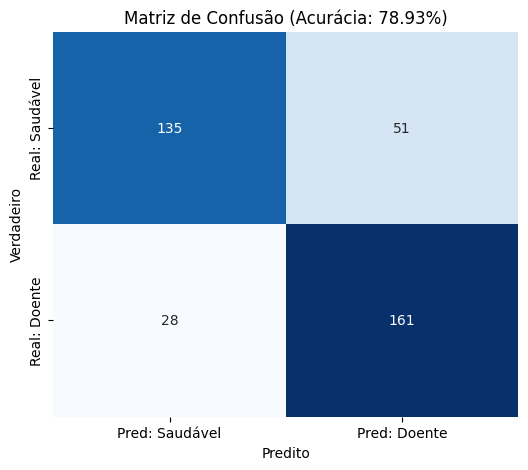

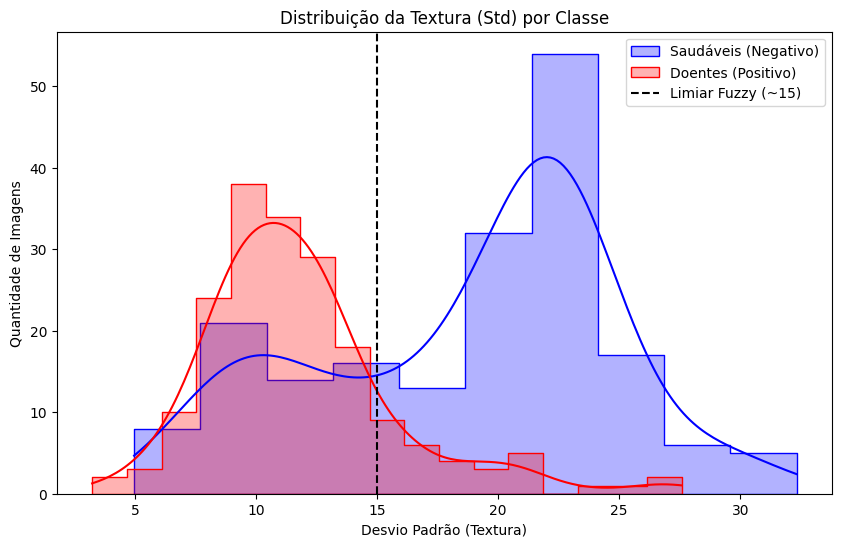